# Shor's Order-Finding Algorithm — Benchmarking on IBM Quantum Hardware

> Systematic benchmarking of Shor's algorithm across ideal simulation, noisy simulation, and real IBM Quantum hardware.

This notebook imports circuit definitions and metrics from the `src/` package.

In [1]:
# Install / upgrade dependencies (run once)
!pip3 install -q 'qiskit>=2.1.0' 'qiskit-ibm-runtime>=0.40.1' 'qiskit-aer>=0.17.0' \
    'numpy' 'pandas' 'matplotlib' 'pylatexenc' 'jinja2'

In [2]:
# ─── Imports ───
import os, sys, json, warnings
from datetime import datetime
from fractions import Fraction
from math import floor, gcd, log

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Ensure src/ is importable
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from src.circuits.shor import (
    build_shor_circuit, M2mod15, M4mod15, a2kmodN,
)
from src.metrics.compute import compute_shor_metrics, tvd
from src.simulation import (
    run_ideal, run_noisy, transpile_for_backend, run_hardware,
    SEED_TRANSPILER, SEED_SIMULATOR,
)

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate
from qiskit_ibm_runtime import QiskitRuntimeService

warnings.filterwarnings('ignore', category=DeprecationWarning)
print('All imports successful.')


All imports successful.


## Configuration

In [3]:
# ===========================================
# Experiment Configuration (Profile Driven)
# ===========================================

EXPERIMENT_PROFILE = "AGGRESSIVE_FULL"  # QUICK_7MIN | STANDARD_48 | AGGRESSIVE_FULL
BACKEND_NAME = "ibm_marrakesh"
RUN_HARDWARE = True
OUTPUT_DIR = "./results/shor"

# --- Shor core parameters ---
N = 15
a = 2
num_target = 4  # floor(log2(N-1)) + 1
EPSILON = None  # If None -> 1 / 2^(t+1)

PROFILE_CONFIG = {
    "QUICK_7MIN": {
        "control_sweep": [4, 6],
        "opt_levels": [2],
        "resilience_levels": [0],
        "dd_sweep": [False],
        "shots_sweep": [512, 1024],
        "repetitions": 1,
        "ideal_shots": 100_000,
        "max_hardware_jobs": 3,
        "hardware_budget_minutes": 7,
        "checkpoint_every": 2,
        "backend_variability": False,
        "max_backends": 1,
        "enable_zne_subset": True,
        "zne_target_limit": 2,
        "max_depth_2q_hardware": 260,
        "secondary_phase_enabled": False,
        "secondary_min_remaining_minutes": 30,
        "secondary_min_remaining_jobs": 1,
        "secondary_control_sweep": [6],
        "secondary_shots_sweep": [1024],
        "secondary_repetitions": 1,
        "secondary_opt_levels": [2],
        "secondary_resilience_levels": [0],
        "secondary_dd_sweep": [False],
    },
    "STANDARD_48": {
        "control_sweep": [4, 6, 8],
        "opt_levels": [0, 1, 2, 3],
        "resilience_levels": [0, 1],
        "dd_sweep": [False, True],
        "shots_sweep": [1024],
        "repetitions": 1,
        "ideal_shots": 100_000,
        "max_hardware_jobs": 48,
        "hardware_budget_minutes": 120,
        "checkpoint_every": 8,
        "backend_variability": False,
        "max_backends": 1,
        "enable_zne_subset": False,
        "zne_target_limit": 0,
        "max_depth_2q_hardware": 500,
        "secondary_phase_enabled": False,
        "secondary_min_remaining_minutes": 45,
        "secondary_min_remaining_jobs": 6,
        "secondary_control_sweep": [6, 8],
        "secondary_shots_sweep": [1024],
        "secondary_repetitions": 1,
        "secondary_opt_levels": [2, 3],
        "secondary_resilience_levels": [0, 1],
        "secondary_dd_sweep": [False, True],
    },
    "AGGRESSIVE_FULL": {
        "control_sweep": [4, 6, 8, 10, 12],
        "opt_levels": [0, 1, 2, 3],
        "resilience_levels": [0, 1],
        "dd_sweep": [False, True],
        "shots_sweep": [512, 1024, 2048, 4096],
        "repetitions": 3,
        "ideal_shots": 100_000,
        "max_hardware_jobs": 400,
        "hardware_budget_minutes": 360,
        "checkpoint_every": 12,
        "backend_variability": True,
        "max_backends": 2,
        "enable_zne_subset": True,
        "zne_target_limit": 8,
        "max_depth_2q_hardware": 700,
        "secondary_phase_enabled": True,
        "secondary_min_remaining_minutes": 60,
        "secondary_min_remaining_jobs": 80,
        "secondary_control_sweep": [6, 8, 10],
        "secondary_shots_sweep": [1024, 2048],
        "secondary_repetitions": 1,
        "secondary_opt_levels": [1, 3],
        "secondary_resilience_levels": [0, 1],
        "secondary_dd_sweep": [False, True],
    },
}

if EXPERIMENT_PROFILE not in PROFILE_CONFIG:
    raise ValueError(f"Unknown profile: {EXPERIMENT_PROFILE}")

CFG = PROFILE_CONFIG[EXPERIMENT_PROFILE]
CONTROL_QUBIT_SWEEP = CFG["control_sweep"]
OPT_LEVEL_SWEEP = CFG["opt_levels"]
RESILIENCE_LEVEL_SWEEP = CFG["resilience_levels"]
DD_SWEEP = CFG["dd_sweep"]
SHOTS_SWEEP = CFG["shots_sweep"]
REPETITIONS = CFG["repetitions"]
IDEAL_SHOTS = CFG["ideal_shots"]
MAX_HARDWARE_JOBS = CFG["max_hardware_jobs"]
HARDWARE_BUDGET_MINUTES = CFG["hardware_budget_minutes"]
CHECKPOINT_EVERY = CFG["checkpoint_every"]
BACKEND_VARIABILITY = CFG["backend_variability"]
MAX_BACKENDS = CFG["max_backends"]
ENABLE_ZNE_SUBSET = CFG["enable_zne_subset"]
ZNE_TARGET_CONFIG_LIMIT = CFG["zne_target_limit"]
MAX_DEPTH_2Q_HARDWARE = CFG["max_depth_2q_hardware"]

# Secondary backend phase controls (primary backend always runs full matrix first).
SECONDARY_PHASE_ENABLED = CFG.get("secondary_phase_enabled", False)
SECONDARY_MIN_REMAINING_MINUTES = CFG.get("secondary_min_remaining_minutes", 60)
SECONDARY_MIN_REMAINING_JOBS = CFG.get(
    "secondary_min_remaining_jobs", max(1, int(0.2 * MAX_HARDWARE_JOBS))
)
SECONDARY_CONTROL_SWEEP = CFG.get("secondary_control_sweep", CONTROL_QUBIT_SWEEP[-2:])
SECONDARY_SHOTS_SWEEP = CFG.get("secondary_shots_sweep", [SHOTS_SWEEP[0], SHOTS_SWEEP[-1]])
SECONDARY_REPETITIONS = CFG.get("secondary_repetitions", 1)
SECONDARY_OPT_LEVEL_SWEEP = CFG.get("secondary_opt_levels", OPT_LEVEL_SWEEP[-2:])
SECONDARY_RESILIENCE_LEVEL_SWEEP = CFG.get("secondary_resilience_levels", RESILIENCE_LEVEL_SWEEP)
SECONDARY_DD_SWEEP = CFG.get("secondary_dd_sweep", [False, True])


def dedupe_keep_order(items):
    seen = set()
    out = []
    for item in items:
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out


SECONDARY_CONTROL_SWEEP = [
    c for c in dedupe_keep_order(SECONDARY_CONTROL_SWEEP) if c in CONTROL_QUBIT_SWEEP
]
if not SECONDARY_CONTROL_SWEEP:
    SECONDARY_CONTROL_SWEEP = [CONTROL_QUBIT_SWEEP[-1]]

SECONDARY_SHOTS_SWEEP = [s for s in dedupe_keep_order(SECONDARY_SHOTS_SWEEP) if s in SHOTS_SWEEP]
if not SECONDARY_SHOTS_SWEEP:
    SECONDARY_SHOTS_SWEEP = [SHOTS_SWEEP[0]]

SECONDARY_OPT_LEVEL_SWEEP = [o for o in dedupe_keep_order(SECONDARY_OPT_LEVEL_SWEEP) if o in OPT_LEVEL_SWEEP]
if not SECONDARY_OPT_LEVEL_SWEEP:
    SECONDARY_OPT_LEVEL_SWEEP = [OPT_LEVEL_SWEEP[-1]]

SECONDARY_RESILIENCE_LEVEL_SWEEP = [
    r for r in dedupe_keep_order(SECONDARY_RESILIENCE_LEVEL_SWEEP) if r in RESILIENCE_LEVEL_SWEEP
]
if not SECONDARY_RESILIENCE_LEVEL_SWEEP:
    SECONDARY_RESILIENCE_LEVEL_SWEEP = [RESILIENCE_LEVEL_SWEEP[0]]

SECONDARY_DD_SWEEP = [d for d in dedupe_keep_order(SECONDARY_DD_SWEEP) if d in DD_SWEEP]
if not SECONDARY_DD_SWEEP:
    SECONDARY_DD_SWEEP = [DD_SWEEP[0]]

SECONDARY_REPETITIONS = max(1, int(SECONDARY_REPETITIONS))

# ZNE proxy noise scaling (same idea as Grover notebook).
ZNE_SCALE_FACTORS = [1.0, 1.5, 2.0]

RUN_SIMULATION_TIERS = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Profile: {EXPERIMENT_PROFILE}")
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"Control sweep: {CONTROL_QUBIT_SWEEP}")
print(f"Shots sweep: {SHOTS_SWEEP}; repetitions={REPETITIONS}")
print(f"Depth guard (2q depth): {MAX_DEPTH_2Q_HARDWARE}")
print("Primary-first policy:")
print(f"  Secondary phase enabled: {SECONDARY_PHASE_ENABLED}")
print(f"  Secondary thresholds: minutes>={SECONDARY_MIN_REMAINING_MINUTES}, jobs>={SECONDARY_MIN_REMAINING_JOBS}")
print(f"  Secondary subset control={SECONDARY_CONTROL_SWEEP}, shots={SECONDARY_SHOTS_SWEEP}, reps={SECONDARY_REPETITIONS}")

Profile: AGGRESSIVE_FULL
Output directory: /Users/destroy/Documents/GitHub/autoQiskit/src/results/shor
Control sweep: [4, 6, 8, 10, 12]
Shots sweep: [512, 1024, 2048, 4096]; repetitions=3
Depth guard (2q depth): 700
Primary-first policy:
  Secondary phase enabled: True
  Secondary thresholds: minutes>=60, jobs>=80
  Secondary subset control=[6, 8, 10], shots=[1024, 2048], reps=1


## Authentication & Backend Selection

In [4]:
# --- Authentication ---
service = None

try:
    service = QiskitRuntimeService()
    print("Loaded saved IBM Quantum account.")
except Exception:
    pass

if service is None:
    for path in [
        "apikey.json",
        os.path.join(os.path.dirname(os.path.abspath(".")), "apikey.json"),
    ]:
        if os.path.exists(path):
            try:
                with open(path) as f:
                    apidata = json.load(f)
                token = apidata.get("apikey", "")
                if token:
                    QiskitRuntimeService.save_account(
                        channel="ibm_quantum_platform", token=token, overwrite=True
                    )
                    service = QiskitRuntimeService()
                    print(f"Loaded token from {path}")
                    break
            except Exception:
                continue

if service is None:
    from getpass import getpass

    token = getpass("Enter your IBM Quantum API token: ")
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform", token=token, overwrite=True
    )
    service = QiskitRuntimeService()
    print("Token saved and account loaded.")


# --- Backend Selection ---
def pending_jobs_safe(candidate_backend):
    try:
        return int(candidate_backend.status().pending_jobs)
    except Exception:
        return 10**9


min_qubits = max(CONTROL_QUBIT_SWEEP) + num_target

primary_backend = None
if BACKEND_NAME:
    try:
        primary_backend = service.backend(BACKEND_NAME)
        if primary_backend.num_qubits < min_qubits:
            print(
                f"WARNING: {BACKEND_NAME} has only {primary_backend.num_qubits} qubits "
                f"(need >= {min_qubits}). Falling back to least_busy."
            )
            primary_backend = service.least_busy(
                operational=True, simulator=False, min_num_qubits=min_qubits
            )
    except Exception as exc:
        print(f"Backend {BACKEND_NAME} unavailable ({exc}), using least_busy.")
        primary_backend = service.least_busy(
            operational=True, simulator=False, min_num_qubits=min_qubits
        )
else:
    primary_backend = service.least_busy(
        operational=True, simulator=False, min_num_qubits=min_qubits
    )

backend_pool = [primary_backend]

if BACKEND_VARIABILITY and MAX_BACKENDS > 1:
    try:
        all_candidates = service.backends(operational=True, simulator=False)
        extra_candidates = [
            b
            for b in all_candidates
            if b.num_qubits >= min_qubits and b.name != primary_backend.name
        ]
        extra_candidates = sorted(extra_candidates, key=pending_jobs_safe)

        for candidate in extra_candidates:
            if len(backend_pool) >= MAX_BACKENDS:
                break
            backend_pool.append(candidate)
    except Exception as exc:
        print(f"Backend variability discovery failed: {exc}")

# Deduplicate by backend name while preserving order.
seen = set()
dedup_pool = []
for b in backend_pool:
    if b.name not in seen:
        seen.add(b.name)
        dedup_pool.append(b)
backend_pool = dedup_pool

PRIMARY_BACKEND = backend_pool[0]
BACKEND_NAMES = [b.name for b in backend_pool]

# If backend capacity is below the configured largest sweep, shrink sweep safely.
max_supported_control = PRIMARY_BACKEND.num_qubits - num_target
if max_supported_control < max(CONTROL_QUBIT_SWEEP):
    old_sweep = CONTROL_QUBIT_SWEEP[:]
    CONTROL_QUBIT_SWEEP = [c for c in CONTROL_QUBIT_SWEEP if c <= max_supported_control]
    print(
        "Adjusted CONTROL_QUBIT_SWEEP due to backend capacity: "
        f"{old_sweep} -> {CONTROL_QUBIT_SWEEP}"
    )
    if not CONTROL_QUBIT_SWEEP:
        raise RuntimeError(
            "No valid control-qubit values remain for selected backend capacity."
        )

print("Backend pool:")
for idx, b in enumerate(backend_pool, start=1):
    print(f"  [{idx}] {b.name} ({b.num_qubits} qubits)")
print(f"Primary backend: {PRIMARY_BACKEND.name}")

qiskit_runtime_service.__init__:WARNING:2026-04-04 20:37:37,705: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Qiskit-GRM. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-04 20:37:37,707: Using instance: Qiskit-GRM, plan: open


Loaded saved IBM Quantum account.


qiskit_runtime_service.backends:WARNING:2026-04-04 20:37:39,455: Loading instance: Qiskit-GRM, plan: open


Backend pool:
  [1] ibm_marrakesh (156 qubits)
  [2] ibm_kingston (156 qubits)
Primary backend: ibm_marrakesh


---
## Circuit Components

The modular multiplication gates (M2, M4), repeated squaring helper, and full Shor circuit are imported from `src.circuits.shor`.

In [5]:
# ─── a^{2^k} mod N sequence ───
k_list = range(8)
b_list = [a2kmodN(2, k, 15) for k in k_list]
print(f'a=2, N=15: a^(2^k) mod N for k=0..7: {b_list}')


a=2, N=15: a^(2^k) mod N for k=0..7: [2, 4, 1, 1, 1, 1, 1, 1]


Shor circuit: 12 qubits, 8 classical bits


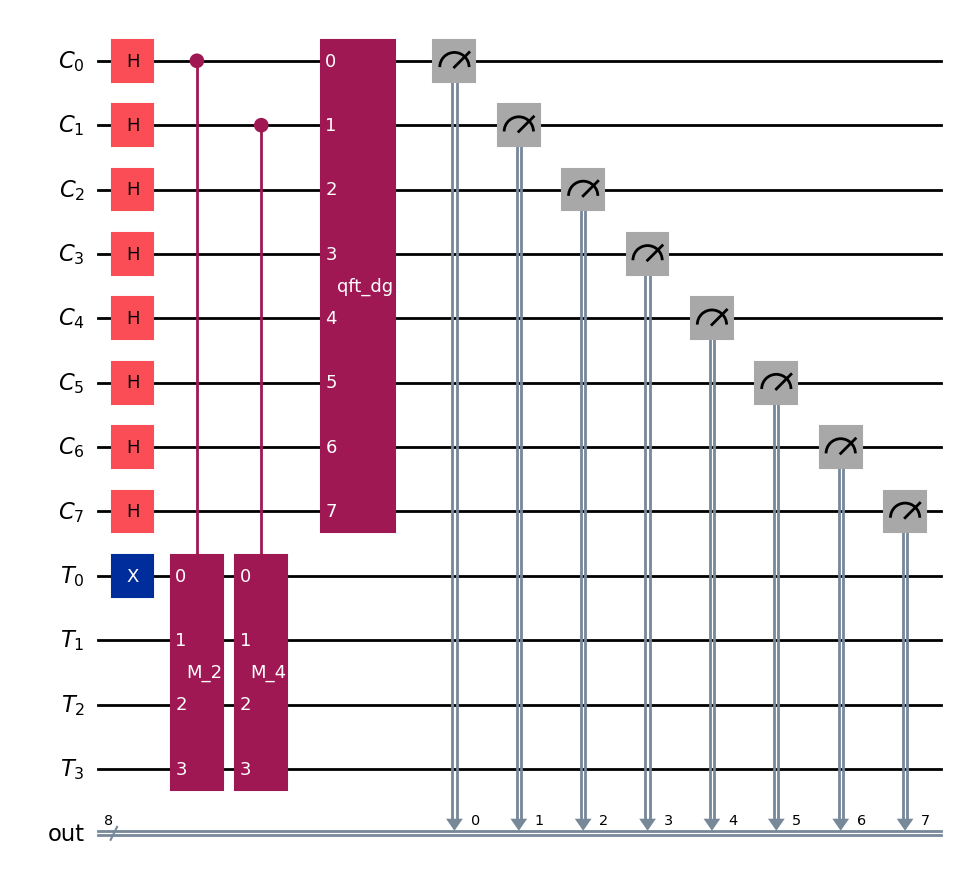

In [6]:
# ─── Circuit visualisation ───
qc = build_shor_circuit(num_control=8, num_target=4, a=a, N=N)
print(f'Shor circuit: {qc.num_qubits} qubits, {qc.num_clbits} classical bits')
qc.draw('mpl', fold=-1)


---
## Experiment Sweep

48-configuration factorial sweep: 4 opt levels x 3 control sizes x 2 resilience x 2 DD.

In [7]:
# ===========================================
# Run Expanded Experiments
# ===========================================
from itertools import product
import time

from src.simulation import make_generic_noise_model

all_results = []
all_distributions = {}
run_counter = 0
hardware_jobs_submitted = 0
hardware_budget_exhausted = False
zne_evaluations = 0
experiment_start = time.time()

SECONDARY_PHASE_EXECUTED = False
SECONDARY_PHASE_REASON = "not_evaluated"
SECONDARY_PHASE_BACKENDS = []


def zne_proxy_success_estimate_shor(circuit, ideal_dist, num_control, shots, epsilon):
    """Lightweight ZNE proxy on noisy simulation by scaling depolarizing noise."""
    scale_to_success = {}
    for scale in ZNE_SCALE_FACTORS:
        err_1q = min(0.49, 0.001 * scale)
        err_2q = min(0.49, 0.01 * scale)
        scaled_noise = make_generic_noise_model(err_1q=err_1q, err_2q=err_2q)
        dist_scaled = run_noisy(circuit, shots=shots, noise_model=scaled_noise)
        metrics_scaled = compute_shor_metrics(
            dist_scaled,
            ideal_dist,
            num_control,
            a=a,
            N=N,
            epsilon=epsilon,
        )
        scale_to_success[scale] = metrics_scaled["success_prob"]

    x = np.array(sorted(scale_to_success.keys()), dtype=float)
    y = np.array([scale_to_success[k] for k in x], dtype=float)
    coeff = np.polyfit(x, y, 1)
    est_zero_noise = float(np.clip(coeff[1], 0.0, 1.0))

    return {
        "zne_scales": list(x),
        "zne_success_by_scale": {str(k): float(v) for k, v in scale_to_success.items()},
        "zne_success_estimate": est_zero_noise,
        "zne_fit_slope": float(coeff[0]),
    }


def checkpoint_results(rows, output_dir, suffix):
    if not rows:
        return
    ckpt_df = pd.DataFrame(rows)
    ckpt_csv = os.path.join(output_dir, f"shor_results_checkpoint_{suffix}.csv")
    ckpt_df.to_csv(ckpt_csv, index=False)
    print(f"Checkpoint saved: {ckpt_csv}")


def remaining_budget_state():
    elapsed_minutes = (time.time() - experiment_start) / 60.0
    remaining_minutes = max(0.0, HARDWARE_BUDGET_MINUTES - elapsed_minutes)
    remaining_jobs = max(0, MAX_HARDWARE_JOBS - hardware_jobs_submitted)
    return elapsed_minutes, remaining_minutes, remaining_jobs


def can_start_secondary_phase():
    if not SECONDARY_PHASE_ENABLED:
        return False, "secondary_phase_disabled"
    if len(backend_pool) <= 1:
        return False, "no_secondary_backend_available"
    if not RUN_HARDWARE:
        return False, "hardware_disabled"
    if hardware_budget_exhausted:
        return False, "hardware_budget_already_exhausted"

    _, remaining_minutes, remaining_jobs = remaining_budget_state()
    if remaining_minutes < SECONDARY_MIN_REMAINING_MINUTES:
        return False, f"insufficient_remaining_minutes:{remaining_minutes:.1f}"
    if remaining_jobs < SECONDARY_MIN_REMAINING_JOBS:
        return False, f"insufficient_remaining_jobs:{remaining_jobs}"

    return True, "secondary_phase_enabled"


phase_plan = [
    {
        "name": "primary",
        "scope": "primary_full",
        "backends": [PRIMARY_BACKEND],
        "control_sweep": CONTROL_QUBIT_SWEEP,
        "shots_sweep": SHOTS_SWEEP,
        "repetitions": REPETITIONS,
        "opt_levels": OPT_LEVEL_SWEEP,
        "resilience_levels": RESILIENCE_LEVEL_SWEEP,
        "dd_sweep": DD_SWEEP,
    }
]

secondary_ok, secondary_reason = can_start_secondary_phase()
if secondary_ok:
    SECONDARY_PHASE_EXECUTED = True
    SECONDARY_PHASE_REASON = "started"
    SECONDARY_PHASE_BACKENDS = [b.name for b in backend_pool[1:]]
    phase_plan.append(
        {
            "name": "secondary",
            "scope": "secondary_subset",
            "backends": backend_pool[1:],
            "control_sweep": SECONDARY_CONTROL_SWEEP,
            "shots_sweep": SECONDARY_SHOTS_SWEEP,
            "repetitions": SECONDARY_REPETITIONS,
            "opt_levels": SECONDARY_OPT_LEVEL_SWEEP,
            "resilience_levels": SECONDARY_RESILIENCE_LEVEL_SWEEP,
            "dd_sweep": SECONDARY_DD_SWEEP,
        }
    )
else:
    SECONDARY_PHASE_EXECUTED = False
    SECONDARY_PHASE_REASON = secondary_reason

print("=" * 64)
print("Shor expanded sweep started")
print(f"Profile={EXPERIMENT_PROFILE} | RUN_HARDWARE={RUN_HARDWARE}")
print(f"Backend pool={BACKEND_NAMES}")
print(f"Phase plan={[p['name'] for p in phase_plan]}")
if not SECONDARY_PHASE_EXECUTED:
    print(f"Secondary phase skipped: {SECONDARY_PHASE_REASON}")
print("=" * 64)

for phase in phase_plan:
    print(f"\n[Phase: {phase['name']}] scope={phase['scope']}")

    for backend in phase["backends"]:
        print(f"\nBackend: {backend.name}")

        feasible_control_sweep = [
            nc for nc in phase["control_sweep"] if (nc + num_target) <= backend.num_qubits
        ]
        if not feasible_control_sweep:
            print(
                f"No feasible control values for backend {backend.name} with total-qubit limit {backend.num_qubits}."
            )
            continue

        for nc in feasible_control_sweep:
            qc = build_shor_circuit(num_control=nc, num_target=num_target, a=a, N=N)

            print(
                f"\n{'-' * 64}\n"
                f"Control qubits={nc}, total qubits={nc + num_target}, backend={backend.name}\n"
                f"{'-' * 64}"
            )

            ideal_dist = run_ideal(qc, shots=IDEAL_SHOTS)
            ideal_metrics = compute_shor_metrics(
                ideal_dist,
                ideal_dist,
                nc,
                a=a,
                N=N,
                epsilon=EPSILON,
            )
            epsilon_used = ideal_metrics["epsilon"]
            print(f"Ideal success probability={ideal_metrics['success_prob']:.4f}, epsilon={epsilon_used}")

            transpiled_cache = {}
            transpiled_metrics_cache = {}
            for opt_level in phase["opt_levels"]:
                tc, t_metrics = transpile_for_backend(qc, backend, opt_level)
                transpiled_cache[opt_level] = tc
                transpiled_metrics_cache[opt_level] = t_metrics

            for shot_count, opt_level, res_level, dd_enabled, rep_idx in product(
                phase["shots_sweep"],
                phase["opt_levels"],
                phase["resilience_levels"],
                phase["dd_sweep"],
                range(1, phase["repetitions"] + 1),
            ):
                run_counter += 1
                run_id = f"run-{run_counter:05d}"
                timestamp = datetime.utcnow().isoformat() + "Z"
                t_metrics = transpiled_metrics_cache[opt_level]

                row = {
                    "run_id": run_id,
                    "timestamp": timestamp,
                    "profile": EXPERIMENT_PROFILE,
                    "algorithm": "shor",
                    "backend": backend.name,
                    "backend_phase": phase["name"],
                    "backend_scope": phase["scope"],
                    "num_control": nc,
                    "num_target": num_target,
                    "a": a,
                    "N": N,
                    "opt_level": opt_level,
                    "resilience_level": res_level,
                    "dd_enable": dd_enabled,
                    "shots": shot_count,
                    "rep_idx": rep_idx,
                    "run_hardware": RUN_HARDWARE,
                    "depth_2q": t_metrics["depth_2q"],
                    "count_2q": t_metrics["count_2q"],
                    "total_depth": t_metrics["total_depth"],
                    "ideal_success_prob": ideal_metrics["success_prob"],
                    "epsilon": epsilon_used,
                    "skip_reason": None,
                }

                noisy_dist = run_noisy(qc, backend=backend, shots=shot_count)
                noisy_metrics = compute_shor_metrics(
                    noisy_dist,
                    ideal_dist,
                    nc,
                    a=a,
                    N=N,
                    epsilon=EPSILON,
                )
                row["noisy_success_prob"] = noisy_metrics["success_prob"]
                row["tvd_noisy_vs_ideal"] = noisy_metrics["tvd_vs_ideal"]

                do_zne_subset = (
                    ENABLE_ZNE_SUBSET
                    and phase["name"] == "primary"
                    and zne_evaluations < ZNE_TARGET_CONFIG_LIMIT
                    and rep_idx == 1
                    and shot_count == phase["shots_sweep"][0]
                    and opt_level == phase["opt_levels"][-1]
                )

                if do_zne_subset:
                    zne_data = zne_proxy_success_estimate_shor(
                        qc,
                        ideal_dist,
                        nc,
                        shots=shot_count,
                        epsilon=EPSILON,
                    )
                    row["zne_mode"] = "noisy_proxy"
                    row["zne_success_estimate"] = zne_data["zne_success_estimate"]
                    row["zne_fit_slope"] = zne_data["zne_fit_slope"]
                    row["zne_scales"] = json.dumps(zne_data["zne_scales"])
                    row["zne_success_by_scale"] = json.dumps(zne_data["zne_success_by_scale"])
                    zne_evaluations += 1
                else:
                    row["zne_mode"] = "off"
                    row["zne_success_estimate"] = None
                    row["zne_fit_slope"] = None
                    row["zne_scales"] = None
                    row["zne_success_by_scale"] = None

                can_run_hw = RUN_HARDWARE and not hardware_budget_exhausted
                if can_run_hw:
                    elapsed_minutes, _, _ = remaining_budget_state()
                    if hardware_jobs_submitted >= MAX_HARDWARE_JOBS:
                        hardware_budget_exhausted = True
                        can_run_hw = False
                        row["skip_reason"] = "max_hardware_jobs_reached"
                    elif elapsed_minutes >= HARDWARE_BUDGET_MINUTES:
                        hardware_budget_exhausted = True
                        can_run_hw = False
                        row["skip_reason"] = "hardware_time_budget_reached"
                    elif t_metrics["depth_2q"] > MAX_DEPTH_2Q_HARDWARE:
                        can_run_hw = False
                        row["skip_reason"] = (
                            f"depth_guard_exceeded:{t_metrics['depth_2q']}"
                        )

                if can_run_hw:
                    tc = transpiled_cache[opt_level]
                    try:
                        hw_dist, job_id = run_hardware(
                            tc,
                            backend,
                            shots=shot_count,
                            resilience_level=res_level,
                            dd_enable=dd_enabled,
                        )
                        hardware_jobs_submitted += 1

                        hw_metrics = compute_shor_metrics(
                            hw_dist,
                            ideal_dist,
                            nc,
                            a=a,
                            N=N,
                            epsilon=EPSILON,
                            noisy_dist=noisy_dist,
                        )
                        row["hw_success_prob"] = hw_metrics["success_prob"]
                        row["tvd_hw_vs_ideal"] = hw_metrics["tvd_vs_ideal"]
                        row["tvd_hw_vs_noisy"] = hw_metrics.get("tvd_vs_noisy")
                        row["job_id"] = job_id

                        all_distributions[run_id] = {
                            "ideal": ideal_dist,
                            "noisy": noisy_dist,
                            "hardware": hw_dist,
                        }

                        print(
                            f"[{run_id}] phase={phase['name']} shot={shot_count} opt={opt_level} "
                            f"res={res_level} dd={'ON' if dd_enabled else 'OFF'} rep={rep_idx} "
                            f"success={hw_metrics['success_prob']:.4f}"
                        )
                    except Exception as exc:
                        row["hw_success_prob"] = None
                        row["tvd_hw_vs_ideal"] = None
                        row["tvd_hw_vs_noisy"] = None
                        row["job_id"] = None
                        row["skip_reason"] = f"hardware_error:{type(exc).__name__}"
                        print(f"[{run_id}] Hardware execution failed: {exc}")
                else:
                    row["hw_success_prob"] = None
                    row["tvd_hw_vs_ideal"] = None
                    row["tvd_hw_vs_noisy"] = None
                    row["job_id"] = None
                    if row["skip_reason"] is None:
                        if not RUN_HARDWARE:
                            row["skip_reason"] = "hardware_disabled"
                        elif hardware_budget_exhausted:
                            row["skip_reason"] = "budget_exhausted_before_submission"
                        else:
                            row["skip_reason"] = "phase_guard_blocked"

                all_results.append(row)

                if run_counter % CHECKPOINT_EVERY == 0:
                    checkpoint_results(all_results, OUTPUT_DIR, suffix=f"{run_counter:05d}")

print("\n" + "=" * 64)
print(f"Total attempted rows: {run_counter}")
print(f"Hardware jobs submitted: {hardware_jobs_submitted}")
print(f"Hardware budget exhausted: {hardware_budget_exhausted}")
print(f"ZNE subset evaluations: {zne_evaluations}")
print(f"Secondary phase executed: {SECONDARY_PHASE_EXECUTED}")
print(f"Secondary phase reason: {SECONDARY_PHASE_REASON}")
print("=" * 64)

Shor expanded sweep started
Profile=AGGRESSIVE_FULL | RUN_HARDWARE=True
Backend pool=['ibm_marrakesh', 'ibm_kingston']
Phase plan=['primary', 'secondary']

[Phase: primary] scope=primary_full

Backend: ibm_marrakesh

----------------------------------------------------------------
Control qubits=4, total qubits=8, backend=ibm_marrakesh
----------------------------------------------------------------
Ideal success probability=1.0000, epsilon=0.03125
  Submitted job d78jsqik86tc739vc2g0 on ibm_marrakesh
[run-00001] phase=primary shot=512 opt=0 res=0 dd=OFF rep=1 success=0.5156
  Submitted job d78jst9q1efs73d1r8cg on ibm_marrakesh
[run-00002] phase=primary shot=512 opt=0 res=0 dd=OFF rep=2 success=0.4668
  Submitted job d78jt03c6das739hvbtg on ibm_marrakesh
[run-00003] phase=primary shot=512 opt=0 res=0 dd=OFF rep=3 success=0.4395
  Submitted job d78jt2geecps73d790l0 on ibm_marrakesh
[run-00004] phase=primary shot=512 opt=0 res=0 dd=ON rep=1 success=0.6660
  Submitted job d78jt6bc6das739h

/Users/destroy/Documents/GitHub/autoQiskit/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1210: UserWarning: This instance has met its usage limit. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2F3145f63bc31e4852b4c34e05995489fb%3Af5d9e374-a08b-4cb5-b330-c38813943ecf%3A%3A for more details.
  warnings.warn(


  Submitted job d78ldjbc6das739i17lg on ibm_marrakesh
[run-00226] phase=primary shot=512 opt=2 res=1 dd=ON rep=1 success=0.5234


/Users/destroy/Documents/GitHub/autoQiskit/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1210: UserWarning: This instance has met its usage limit. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2F3145f63bc31e4852b4c34e05995489fb%3Af5d9e374-a08b-4cb5-b330-c38813943ecf%3A%3A for more details.
  warnings.warn(


  Submitted job d78ldn1q1efs73d1t430 on ibm_marrakesh
[run-00227] phase=primary shot=512 opt=2 res=1 dd=ON rep=2 success=0.5000


/Users/destroy/Documents/GitHub/autoQiskit/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1210: UserWarning: This instance has met its usage limit. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2F3145f63bc31e4852b4c34e05995489fb%3Af5d9e374-a08b-4cb5-b330-c38813943ecf%3A%3A for more details.
  warnings.warn(


  Submitted job d78ldtik86tc739vdvm0 on ibm_marrakesh


KeyboardInterrupt: 

---
## Results & Analysis

In [13]:
# --- Build DataFrame ---
df = pd.DataFrame(all_results)
print(f"Rows collected: {len(df)}")
if not df.empty:
    display(df.head(20))

# --- Run manifest ---
manifest = {
    "profile": EXPERIMENT_PROFILE,
    "run_hardware": RUN_HARDWARE,
    "rows_total": int(len(df)),
    "rows_with_hardware": int(df["hw_success_prob"].notna().sum()) if not df.empty else 0,
    "rows_skipped": int(df["skip_reason"].notna().sum()) if not df.empty else 0,
    "backends": BACKEND_NAMES,
    "primary_backend": PRIMARY_BACKEND.name,
    "backend_phase_policy": "primary_full_then_secondary_subset",
    "secondary_phase_enabled": SECONDARY_PHASE_ENABLED,
    "secondary_phase_executed": bool(globals().get("SECONDARY_PHASE_EXECUTED", False)),
    "secondary_phase_reason": globals().get("SECONDARY_PHASE_REASON", "unknown"),
    "secondary_phase_backends": globals().get("SECONDARY_PHASE_BACKENDS", []),
    "secondary_phase_thresholds": {
        "min_remaining_minutes": SECONDARY_MIN_REMAINING_MINUTES,
        "min_remaining_jobs": SECONDARY_MIN_REMAINING_JOBS,
    },
    "secondary_subset": {
        "control_sweep": SECONDARY_CONTROL_SWEEP,
        "shots_sweep": SECONDARY_SHOTS_SWEEP,
        "repetitions": SECONDARY_REPETITIONS,
        "opt_levels": SECONDARY_OPT_LEVEL_SWEEP,
        "resilience_levels": SECONDARY_RESILIENCE_LEVEL_SWEEP,
        "dd_sweep": SECONDARY_DD_SWEEP,
    },
    "control_sweep": CONTROL_QUBIT_SWEEP,
    "shots_sweep": SHOTS_SWEEP,
    "repetitions": REPETITIONS,
    "opt_levels": OPT_LEVEL_SWEEP,
    "resilience_levels": RESILIENCE_LEVEL_SWEEP,
    "dd_sweep": DD_SWEEP,
    "zne_enabled": ENABLE_ZNE_SUBSET,
    "max_depth_2q_hardware": MAX_DEPTH_2Q_HARDWARE,
}
print("Run manifest:")
print(json.dumps(manifest, indent=2))

# --- Export CSV ---
csv_path = os.path.join(OUTPUT_DIR, "shor_results.csv")
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")

# --- Export JSON ---
json_payload = {
    "created": datetime.utcnow().isoformat() + "Z",
    "profile": EXPERIMENT_PROFILE,
    "manifest": manifest,
    "shor_params": {"a": a, "N": N, "num_target": num_target},
    "runs": all_results,
    "distributions": {
        rid: {tier: dist for tier, dist in tiers.items()}
        for rid, tiers in all_distributions.items()
    },
}
json_path = os.path.join(OUTPUT_DIR, "shor_results.json")
with open(json_path, "w") as f:
    json.dump(json_payload, f, indent=2, default=str)
print(f"Saved {json_path}")

manifest_path = os.path.join(OUTPUT_DIR, "shor_run_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"Saved {manifest_path}")

# --- Analysis frame for plotting ---
analysis_df = df.copy()
if not analysis_df.empty:
    analysis_df = analysis_df[analysis_df["backend"] == PRIMARY_BACKEND.name]
    analysis_df = analysis_df[analysis_df["rep_idx"] == 1]
    analysis_df = analysis_df[analysis_df["shots"] == max(SHOTS_SWEEP)]

print(f"Analysis rows after filtering: {len(analysis_df)}")

Rows collected: 227


,run_id,timestamp,profile,algorithm,backend,backend_phase,backend_scope,num_control,num_target,a,...,tvd_noisy_vs_ideal,zne_mode,zne_success_estimate,zne_fit_slope,zne_scales,zne_success_by_scale,hw_success_prob,tvd_hw_vs_ideal,tvd_hw_vs_noisy,job_id
0,run-00001,2026-04-04T16:37:55.987917Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.515625,0.484375,0.445312,d78jsqik86tc739vc2g0
1,run-00002,2026-04-04T16:38:09.524392Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.466797,0.533203,0.494141,d78jst9q1efs73d1r8cg
2,run-00003,2026-04-04T16:38:20.851470Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.439453,0.560547,0.521484,d78jt03c6das739hvbtg
3,run-00004,2026-04-04T16:38:31.478547Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.666016,0.333984,0.294922,d78jt2geecps73d790l0
4,run-00005,2026-04-04T16:38:45.670183Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.658203,0.341797,0.302734,d78jt6bc6das739hvc80
5,run-00006,2026-04-04T16:39:00.928925Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.660156,0.339844,0.300781,d78jta2k86tc739vc3fg
6,run-00007,2026-04-04T16:39:16.070173Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.576172,0.423828,0.384766,d78jtdpq1efs73d1r97g
7,run-00008,2026-04-04T16:39:27.235353Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.445312,0.554688,0.515625,d78jtggeecps73d79170
8,run-00009,2026-04-04T16:39:38.104047Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.457031,0.542969,0.503906,d78jtjak86tc739vc3q0
9,run-00010,2026-04-04T16:39:49.618812Z,AGGRESSIVE_FULL,shor,ibm_marrakesh,primary,primary_full,4,4,2,...,0.039062,off,NaN,NaN,NaN,NaN,0.638672,0.361328,0.322266,d78jtmak86tc739vc3ug


Run manifest:
{
  "profile": "AGGRESSIVE_FULL",
  "run_hardware": true,
  "rows_total": 227,
  "rows_with_hardware": 227,
  "rows_skipped": 0,
  "backends": [
    "ibm_marrakesh",
    "ibm_kingston"
  ],
  "primary_backend": "ibm_marrakesh",
  "backend_phase_policy": "primary_full_then_secondary_subset",
  "secondary_phase_enabled": true,
  "secondary_phase_executed": true,
  "secondary_phase_reason": "started",
  "secondary_phase_backends": [
    "ibm_kingston"
  ],
  "secondary_phase_thresholds": {
    "min_remaining_minutes": 60,
    "min_remaining_jobs": 80
  },
  "secondary_subset": {
    "control_sweep": [
      6,
      8,
      10
    ],
    "shots_sweep": [
      1024,
      2048
    ],
    "repetitions": 1,
    "opt_levels": [
      1,
      3
    ],
    "resilience_levels": [
      0,
      1
    ],
    "dd_sweep": [
      false,
      true
    ]
  },
  "control_sweep": [
    4,
    6,
    8,
    10,
    12
  ],
  "shots_sweep": [
    512,
    1024,
    2048,
    4096
  ],
 

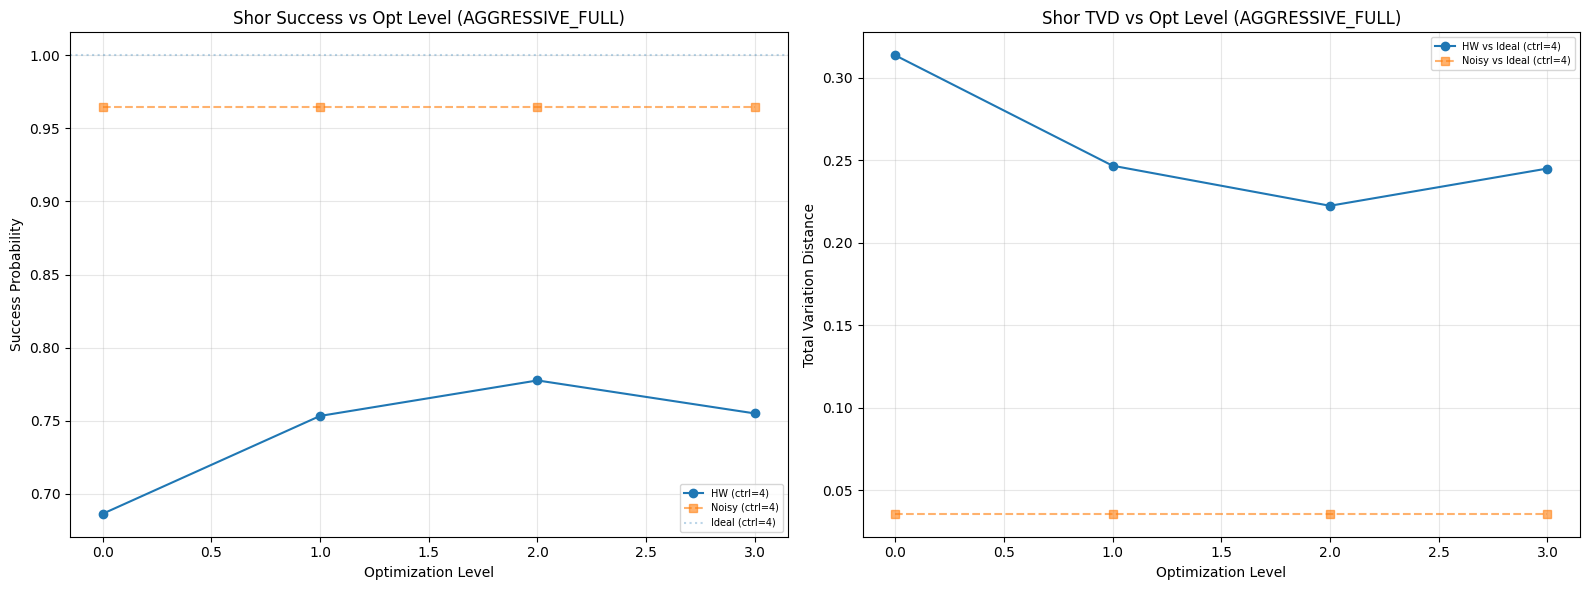

Saved ./results/shor/success_prob_and_tvd.png


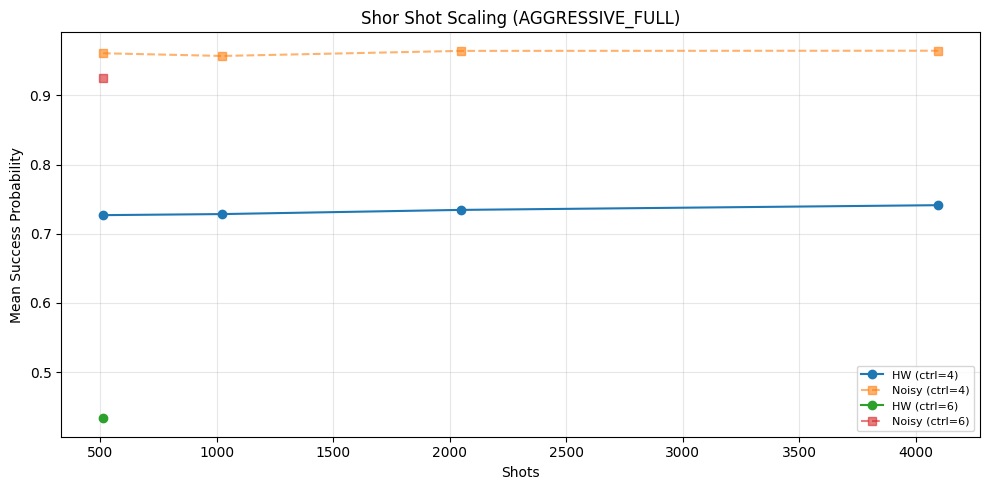

Saved ./results/shor/shot_scaling_success.png


In [14]:
# ===========================================
# Plots (Profile-aware, Aggregated)
# ===========================================
plot_df = analysis_df.copy() if "analysis_df" in globals() else df.copy()
if plot_df.empty:
    print("No data available for plotting.")
else:
    agg = (
        plot_df.groupby(["num_control", "opt_level"], as_index=False)
        .agg(
            hw_success_prob=("hw_success_prob", "mean"),
            noisy_success_prob=("noisy_success_prob", "mean"),
            ideal_success_prob=("ideal_success_prob", "mean"),
            tvd_hw_vs_ideal=("tvd_hw_vs_ideal", "mean"),
            tvd_noisy_vs_ideal=("tvd_noisy_vs_ideal", "mean"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    for nc in sorted(agg["num_control"].unique()):
        sub = agg[agg["num_control"] == nc]
        if sub["hw_success_prob"].notna().any():
            ax.plot(
                sub["opt_level"],
                sub["hw_success_prob"],
                marker="o",
                label=f"HW (ctrl={nc})",
            )
        if sub["noisy_success_prob"].notna().any():
            ax.plot(
                sub["opt_level"],
                sub["noisy_success_prob"],
                marker="s",
                linestyle="--",
                alpha=0.6,
                label=f"Noisy (ctrl={nc})",
            )
        if sub["ideal_success_prob"].notna().any():
            ax.axhline(
                sub["ideal_success_prob"].iloc[0],
                linestyle=":",
                alpha=0.3,
                label=f"Ideal (ctrl={nc})",
            )

    ax.set_xlabel("Optimization Level")
    ax.set_ylabel("Success Probability")
    ax.set_title(f"Shor Success vs Opt Level ({EXPERIMENT_PROFILE})")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for nc in sorted(agg["num_control"].unique()):
        sub = agg[agg["num_control"] == nc]
        if sub["tvd_hw_vs_ideal"].notna().any():
            ax.plot(
                sub["opt_level"],
                sub["tvd_hw_vs_ideal"],
                marker="o",
                label=f"HW vs Ideal (ctrl={nc})",
            )
        if sub["tvd_noisy_vs_ideal"].notna().any():
            ax.plot(
                sub["opt_level"],
                sub["tvd_noisy_vs_ideal"],
                marker="s",
                linestyle="--",
                alpha=0.6,
                label=f"Noisy vs Ideal (ctrl={nc})",
            )

    ax.set_xlabel("Optimization Level")
    ax.set_ylabel("Total Variation Distance")
    ax.set_title(f"Shor TVD vs Opt Level ({EXPERIMENT_PROFILE})")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, "success_prob_and_tvd.png")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fig_path}")

    # --- Optional Plot: Shot Scaling Trend ---
    if df["shots"].nunique() > 1:
        shot_agg = (
            df.groupby(["num_control", "shots"], as_index=False)
            .agg(
                hw_success_prob=("hw_success_prob", "mean"),
                noisy_success_prob=("noisy_success_prob", "mean"),
            )
            .sort_values(["num_control", "shots"])
        )

        fig2, ax2 = plt.subplots(figsize=(10, 5))
        for nc in sorted(shot_agg["num_control"].unique()):
            sub = shot_agg[shot_agg["num_control"] == nc]
            if sub["hw_success_prob"].notna().any():
                ax2.plot(
                    sub["shots"],
                    sub["hw_success_prob"],
                    marker="o",
                    label=f"HW (ctrl={nc})",
                )
            if sub["noisy_success_prob"].notna().any():
                ax2.plot(
                    sub["shots"],
                    sub["noisy_success_prob"],
                    marker="s",
                    linestyle="--",
                    alpha=0.6,
                    label=f"Noisy (ctrl={nc})",
                )

        ax2.set_xlabel("Shots")
        ax2.set_ylabel("Mean Success Probability")
        ax2.set_title(f"Shor Shot Scaling ({EXPERIMENT_PROFILE})")
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=8, loc="best")

        plt.tight_layout()
        shot_fig_path = os.path.join(OUTPUT_DIR, "shot_scaling_success.png")
        fig2.savefig(shot_fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {shot_fig_path}")

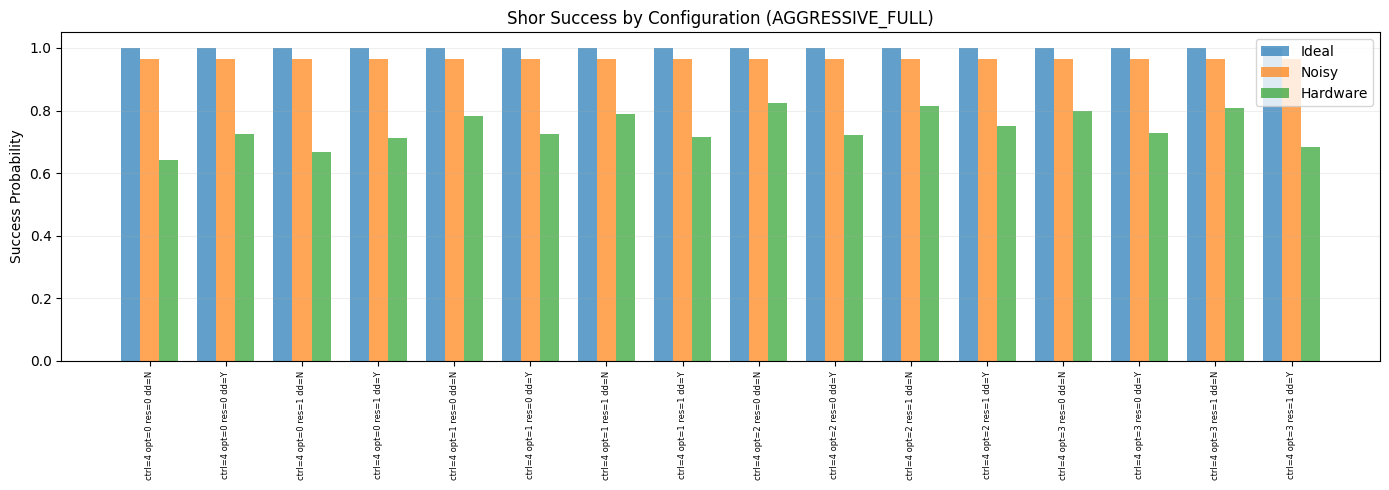

Saved ./results/shor/success_prob_bar.png


In [15]:
# --- Bar chart: success probability by representative configuration ---
bar_df = analysis_df.copy() if "analysis_df" in globals() else df.copy()
if bar_df.empty:
    print("No data available for bar chart.")
else:
    if len(bar_df) > 30:
        bar_df = bar_df.sort_values("hw_success_prob", ascending=False).head(30)

    fig, ax = plt.subplots(figsize=(14, 5))

    labels, hw_vals, noisy_vals, ideal_vals = [], [], [], []
    for _, row in bar_df.iterrows():
        tag = (
            f"ctrl={int(row['num_control'])} opt={int(row['opt_level'])} "
            f"res={int(row['resilience_level'])} dd={'Y' if row['dd_enable'] else 'N'}"
        )
        labels.append(tag)
        hw_vals.append(row.get("hw_success_prob") or 0.0)
        noisy_vals.append(row.get("noisy_success_prob") or 0.0)
        ideal_vals.append(row.get("ideal_success_prob") or 0.0)

    x = np.arange(len(labels))
    w = 0.25
    ax.bar(x - w, ideal_vals, w, label="Ideal", alpha=0.7)
    ax.bar(x, noisy_vals, w, label="Noisy", alpha=0.7)
    ax.bar(x + w, hw_vals, w, label="Hardware", alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_ylabel("Success Probability")
    ax.set_title(f"Shor Success by Configuration ({EXPERIMENT_PROFILE})")
    ax.legend()
    ax.grid(True, alpha=0.2, axis="y")

    plt.tight_layout()
    bar_path = os.path.join(OUTPUT_DIR, "success_prob_bar.png")
    fig.savefig(bar_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {bar_path}")

In [16]:
# --- Summary Table ---
summary_df = analysis_df.copy() if "analysis_df" in globals() else df.copy()
summary_cols = [
    "run_id",
    "profile",
    "backend",
    "backend_phase",
    "backend_scope",
    "num_control",
    "num_target",
    "a",
    "N",
    "shots",
    "rep_idx",
    "opt_level",
    "resilience_level",
    "dd_enable",
    "depth_2q",
    "count_2q",
    "ideal_success_prob",
    "noisy_success_prob",
    "hw_success_prob",
    "tvd_hw_vs_ideal",
    "tvd_noisy_vs_ideal",
    "epsilon",
    "zne_mode",
    "zne_success_estimate",
    "skip_reason",
    "job_id",
]
existing_cols = [c for c in summary_cols if c in summary_df.columns]

if summary_df.empty:
    print("No rows available for summary table.")
else:
    try:
        display(
            summary_df[existing_cols]
            .style.format(precision=4, na_rep="-")
            .set_caption(f"Shor Expanded Sweep Summary ({EXPERIMENT_PROFILE})")
        )
    except AttributeError:
        display(summary_df[existing_cols])

,run_id,profile,backend,backend_phase,backend_scope,num_control,num_target,a,N,shots,rep_idx,opt_level,resilience_level,dd_enable,depth_2q,count_2q,ideal_success_prob,noisy_success_prob,hw_success_prob,tvd_hw_vs_ideal,tvd_noisy_vs_ideal,epsilon,zne_mode,zne_success_estimate,skip_reason,job_id
144,run-00145,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,0,0,False,218,249,1.0000,0.9646,0.6433,0.3567,0.0357,0.0312,off,-,-,d78l2fhq1efs73d1sm70
147,run-00148,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,0,0,True,218,249,1.0000,0.9646,0.7241,0.2759,0.0357,0.0312,off,-,-,d78l2oak86tc739vdhi0
150,run-00151,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,0,1,False,218,249,1.0000,0.9646,0.6665,0.3335,0.0357,0.0312,off,-,-,d78l348eecps73d7aebg
153,run-00154,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,0,1,True,218,249,1.0000,0.9646,0.7112,0.2888,0.0357,0.0312,off,-,-,d78l3cgeecps73d7ael0
156,run-00157,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,1,0,False,188,198,1.0000,0.9646,0.7830,0.2170,0.0357,0.0312,off,-,-,d78l3obc6das739i0qm0
159,run-00160,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,1,0,True,188,198,1.0000,0.9646,0.7236,0.2764,0.0357,0.0312,off,-,-,d78l41bc6das739i0r10
162,run-00163,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,1,1,False,188,198,1.0000,0.9646,0.7893,0.2107,0.0357,0.0312,off,-,-,d78l4cak86tc739vdjag
165,run-00166,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,1,1,True,188,198,1.0000,0.9646,0.7170,0.2830,0.0357,0.0312,off,-,-,d78l4kqk86tc739vdjjg
168,run-00169,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,2,0,False,155,164,1.0000,0.9646,0.8237,0.1763,0.0357,0.0312,off,-,-,d78l4vgeecps73d7agd0
171,run-00172,AGGRESSIVE_FULL,ibm_marrakesh,primary,primary_full,4,4,2,15,4096,1,2,0,True,155,164,1.0000,0.9646,0.7212,0.2788,0.0357,0.0312,off,-,-,d78l57ik86tc739vdkc0


---
## Factor Extraction (Shor's Algorithm Demo)

Using the **best hardware run**, extract candidate factors of N=15 from the measured control-register bitstrings.

Best run: run-00169 (backend=ibm_marrakesh, ctrl=4, success_prob=0.8237, shots=4096)
Peaks above threshold: {'1000': 855, '0000': 996, '0100': 773, '1100': 750}

ATTEMPT 0:
  Phase: theta = 0.500000
  Estimated order r = 2
ATTEMPT 1:
  Phase: theta = 0.000000
  Estimated order r = 1
ATTEMPT 2:
  Phase: theta = 0.250000
  Estimated order r = 4
  *** Non-trivial factor found: 3 ***
  15 = 3 x 5


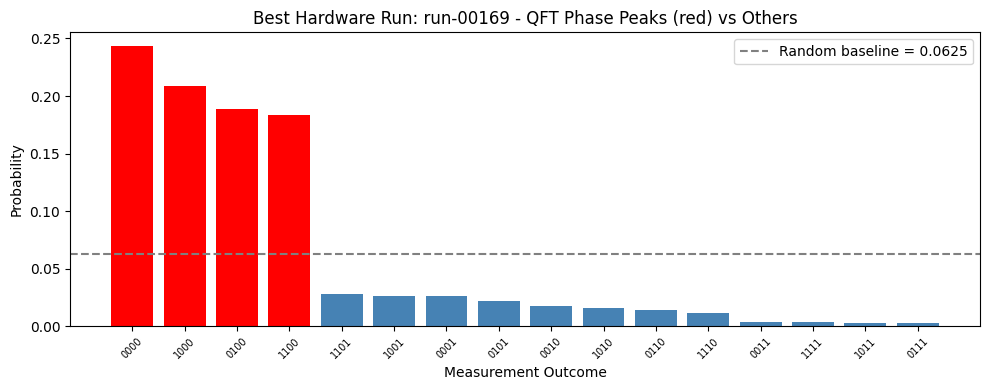

Saved ./results/shor/factor_extraction.png


In [17]:
# --- Factor Extraction from Best Hardware Run ---
verification_df = analysis_df.copy() if "analysis_df" in globals() else df.copy()

if RUN_HARDWARE and not verification_df.empty and verification_df["hw_success_prob"].notna().any():
    candidate_df = verification_df[verification_df["hw_success_prob"].notna()].copy()
    best_row = candidate_df.loc[candidate_df["hw_success_prob"].idxmax()]

    best_id = best_row["run_id"]
    best_nc = int(best_row["num_control"])
    hw_dist = all_distributions.get(best_id, {}).get("hardware", {})

    if hw_dist:
        counts = {k: int(v * best_row["shots"]) for k, v in hw_dist.items()}
        threshold = max(counts.values()) / 2
        counts_keep = {k: v for k, v in counts.items() if v > threshold}

        print(
            f"Best run: {best_id} (backend={best_row['backend']}, ctrl={best_nc}, "
            f"success_prob={best_row['hw_success_prob']:.4f}, shots={int(best_row['shots'])})"
        )
        print(f"Peaks above threshold: {counts_keep}\n")

        factor_found = False
        for idx, bitstring in enumerate(counts_keep):
            print(f"ATTEMPT {idx}:")
            decimal = int(bitstring, 2)
            phase = decimal / (2 ** best_nc)
            print(f"  Phase: theta = {phase:.6f}")

            frac = Fraction(phase).limit_denominator(N)
            r = frac.denominator
            print(f"  Estimated order r = {r}")

            if phase != 0 and r % 2 == 0:
                x_val = pow(a, r // 2, N) - 1
                d = gcd(x_val, N)
                if d > 1 and d != N:
                    factor_found = True
                    print(f"  *** Non-trivial factor found: {d} ***")
                    print(f"  {N} = {d} x {N // d}")
                    break

        if not factor_found:
            print("No non-trivial factor found from the filtered peaks.")

        expected_phases = [k / 4 for k in range(4)]
        expected_bs = {
            format(round(p * (2 ** best_nc)), f"0{best_nc}b") for p in expected_phases
        }

        sorted_dist = dict(
            sorted(hw_dist.items(), key=lambda x: x[1], reverse=True)[: min(20, len(hw_dist))]
        )
        colors = ["red" if k in expected_bs else "steelblue" for k in sorted_dist]

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(sorted_dist.keys(), sorted_dist.values(), color=colors)
        random_p = 1.0 / (2 ** best_nc)
        ax.axhline(
            y=random_p,
            color="gray",
            linestyle="--",
            label=f"Random baseline = {random_p:.4f}",
        )
        ax.set_xlabel("Measurement Outcome")
        ax.set_ylabel("Probability")
        ax.set_title(
            f"Best Hardware Run: {best_id} - QFT Phase Peaks (red) vs Others"
        )
        ax.legend()
        plt.xticks(rotation=45, fontsize=7)
        plt.tight_layout()

        out_path = os.path.join(OUTPUT_DIR, "factor_extraction.png")
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {out_path}")
    else:
        print("No hardware distribution available for factor extraction.")
else:
    print("Hardware runs were disabled or no hardware results are available.")

---
## How to Run on IBM Hardware

| File | Content |
|------|---------|
| `results/shor/shor_results.csv` | Flat table with all metrics per run |
| `results/shor/shor_results.json` | Full distributions + metadata |
| `results/shor/success_prob_and_tvd.png` | Line plots of success prob & TVD |
| `results/shor/success_prob_bar.png` | Bar chart across all configs |
| `results/shor/factor_extraction.png` | Best-run phase histogram with QFT peaks |
